## RQ3 — Incumbency, Governing Party, and Positive Rhetoric
## *Words in Power, Words in Opposition* — ENSAE NLP Project 2026
### Author: Salma El-Aazdoudi

## Research Question

> **Does local unemployment shape the emotional tone of campaign manifestos?**


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("df_full_merged.csv")

# ── Variable chômage départemental (lagged) ───────────────────────────────
chomage_data = {
    "01": {1980: 4.8, 1992: 8.2},   "02": {1980: 7.1, 1992: 11.4},
    "03": {1980: 5.2, 1992: 9.1},   "04": {1980: 6.3, 1992: 10.8},
    "05": {1980: 5.9, 1992: 9.7},   "06": {1980: 6.2, 1992: 10.1},
    "07": {1980: 5.8, 1992: 9.9},   "08": {1980: 7.8, 1992: 13.2},
    "09": {1980: 6.1, 1992: 10.5},  "10": {1980: 5.6, 1992: 9.4},
    "11": {1980: 9.4, 1992: 15.1},  "12": {1980: 5.1, 1992: 8.7},
    "13": {1980: 9.8, 1992: 14.6},  "14": {1980: 6.3, 1992: 10.9},
    "15": {1980: 4.2, 1992: 7.3},   "16": {1980: 6.1, 1992: 10.3},
    "17": {1980: 6.8, 1992: 11.2},  "18": {1980: 5.9, 1992: 9.8},
    "19": {1980: 4.9, 1992: 8.4},   "21": {1980: 5.4, 1992: 9.2},
    "22": {1980: 6.8, 1992: 11.5},  "23": {1980: 5.3, 1992: 8.9},
    "24": {1980: 6.4, 1992: 10.6},  "25": {1980: 4.7, 1992: 8.1},
    "26": {1980: 6.9, 1992: 11.3},  "27": {1980: 6.2, 1992: 10.7},
    "28": {1980: 5.3, 1992: 9.0},   "29": {1980: 6.4, 1992: 10.8},
    "30": {1980: 8.7, 1992: 13.9},  "31": {1980: 6.7, 1992: 11.0},
    "32": {1980: 5.6, 1992: 9.5},   "33": {1980: 7.8, 1992: 12.4},
    "34": {1980: 9.1, 1992: 14.3},  "35": {1980: 5.6, 1992: 9.3},
    "36": {1980: 5.8, 1992: 9.7},   "37": {1980: 5.5, 1992: 9.1},
    "38": {1980: 5.3, 1992: 9.0},   "39": {1980: 4.9, 1992: 8.3},
    "40": {1980: 6.3, 1992: 10.4},  "41": {1980: 5.4, 1992: 9.2},
    "42": {1980: 6.8, 1992: 11.4},  "43": {1980: 4.6, 1992: 7.9},
    "44": {1980: 7.1, 1992: 11.6},  "45": {1980: 5.7, 1992: 9.6},
    "46": {1980: 5.2, 1992: 8.8},   "47": {1980: 6.4, 1992: 10.5},
    "48": {1980: 4.3, 1992: 7.4},   "49": {1980: 5.8, 1992: 9.7},
    "50": {1980: 5.9, 1992: 10.0},  "51": {1980: 6.1, 1992: 10.3},
    "52": {1980: 6.3, 1992: 10.7},  "53": {1980: 5.2, 1992: 8.8},
    "54": {1980: 8.9, 1992: 14.1},  "55": {1980: 7.2, 1992: 12.1},
    "56": {1980: 7.3, 1992: 12.0},  "57": {1980: 7.8, 1992: 13.0},
    "58": {1980: 5.6, 1992: 9.4},   "59": {1980: 11.2, 1992: 16.8},
    "60": {1980: 6.4, 1992: 10.8},  "61": {1980: 6.2, 1992: 10.4},
    "62": {1980: 11.8, 1992: 17.3}, "63": {1980: 5.4, 1992: 9.1},
    "64": {1980: 6.8, 1992: 11.2},  "65": {1980: 5.7, 1992: 9.6},
    "66": {1980: 9.2, 1992: 14.5},  "67": {1980: 4.9, 1992: 8.4},
    "68": {1980: 5.1, 1992: 8.7},   "69": {1980: 5.6, 1992: 9.4},
    "70": {1980: 5.3, 1992: 9.0},   "71": {1980: 6.1, 1992: 10.3},
    "72": {1980: 5.4, 1992: 9.1},   "73": {1980: 4.8, 1992: 8.2},
    "74": {1980: 4.3, 1992: 7.5},   "75": {1980: 6.8, 1992: 10.9},
    "76": {1980: 7.6, 1992: 12.5},  "77": {1980: 5.1, 1992: 8.8},
    "78": {1980: 4.9, 1992: 8.3},   "79": {1980: 5.3, 1992: 8.9},
    "80": {1980: 7.9, 1992: 13.1},  "81": {1980: 7.3, 1992: 11.9},
    "82": {1980: 6.2, 1992: 10.3},  "83": {1980: 8.4, 1992: 13.2},
    "84": {1980: 8.8, 1992: 13.9},  "85": {1980: 5.2, 1992: 8.8},
    "86": {1980: 5.8, 1992: 9.7},   "87": {1980: 5.4, 1992: 9.1},
    "88": {1980: 6.3, 1992: 10.5},  "89": {1980: 5.6, 1992: 9.4},
    "90": {1980: 5.8, 1992: 9.6},   "91": {1980: 5.2, 1992: 8.9},
    "92": {1980: 5.4, 1992: 9.1},   "93": {1980: 9.3, 1992: 14.8},
    "94": {1980: 5.9, 1992: 9.8},   "95": {1980: 5.6, 1992: 9.3},
}

def get_chomage(row):
    dept = str(row["departement-insee"]).zfill(2)[:2]
    lag_year = 1980 if row["year"] == 1981 else 1992
    return chomage_data.get(dept, {}).get(lag_year, np.nan)

df["chomage_dept"] = df.apply(get_chomage, axis=1)

print(f"Chômage coverage: {df['chomage_dept'].notna().sum():,} / {len(df):,} ({df['chomage_dept'].notna().mean()*100:.1f}%)")
print(f"\n{df['chomage_dept'].describe().round(2)}")

Chômage coverage: 6,371 / 6,446 (98.8%)

count    6371.00
mean        9.50
std         2.98
min         4.20
25%         7.10
50%         9.30
75%        11.20
max        17.30
Name: chomage_dept, dtype: float64


In [3]:
sns.set_theme(style="whitegrid", font_scale=1.1)

BLOC_ORDER  = ["far_left", "left", "ecologist", "right", "far_right"]
BLOC_COLORS = {"far_left": "#7c3aed", "left": "#185FA5", "ecologist": "#16a34a",
               "right": "#A32D2D", "far_right": "#c2410c"}

# ── 1. Distribution du chômage ────────────────────────────────────────────
print(df["chomage_dept"].describe().round(2))
print(f"\nCorrelation chomage vs tr_intensity_nrc : {df['chomage_dept'].corr(df['tr_intensity_nrc']):.3f}")
print(f"Correlation chomage vs tr_joy           : {df['chomage_dept'].corr(df['tr_joy']):.3f}")
print(f"Correlation chomage vs tr_anger         : {df['chomage_dept'].corr(df['tr_anger']):.3f}")
print(f"Correlation chomage vs tr_fear          : {df['chomage_dept'].corr(df['tr_fear']):.3f}")

# ── 2. Quintiles de chômage ───────────────────────────────────────────────
df["chomage_q"] = pd.qcut(df["chomage_dept"], q=5,
                           labels=["Q1\n(lowest)", "Q2", "Q3", "Q4", "Q5\n(highest)"])

count    6371.00
mean        9.50
std         2.98
min         4.20
25%         7.10
50%         9.30
75%        11.20
max        17.30
Name: chomage_dept, dtype: float64

Correlation chomage vs tr_intensity_nrc : 0.194
Correlation chomage vs tr_joy           : -0.158
Correlation chomage vs tr_anger         : 0.185
Correlation chomage vs tr_fear          : 0.161


## 1. Descriptive Patterns: Emotional Tone by Unemployment Quintile

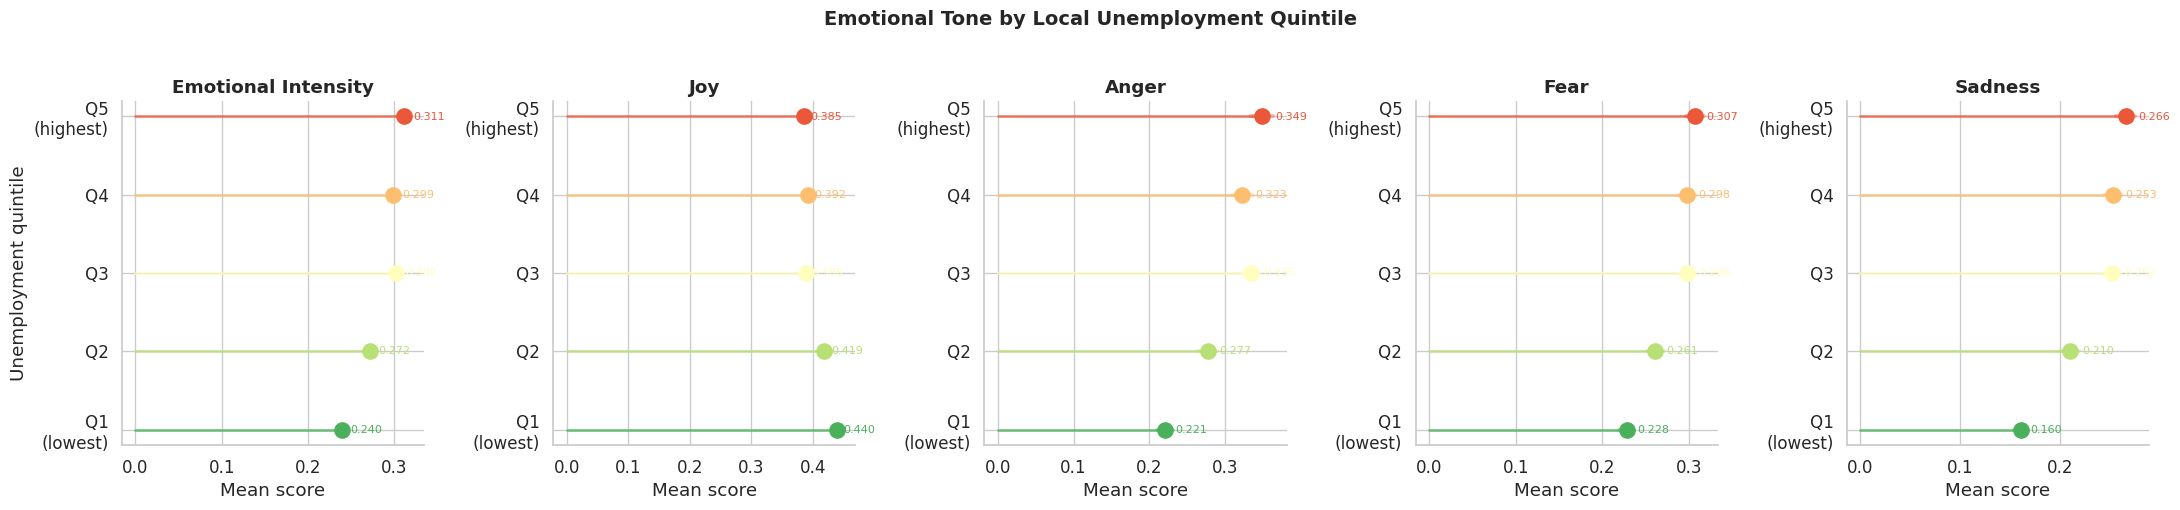

In [4]:
# ── 3. Visualisation : scores par quintile de chômage ────────────────────
TARGET_COLS = {
    "tr_intensity_nrc": "Emotional Intensity",
    "tr_joy":           "Joy",
    "tr_anger":         "Anger",
    "tr_fear":          "Fear",
    "tr_sadness":       "Sadness",
}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Emotional Tone by Local Unemployment Quintile",
             fontsize=14, fontweight="bold", y=1.02)

for ax, (col, label) in zip(axes, TARGET_COLS.items()):
    stats = (
        df.groupby("chomage_q")[col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])

    # Lollipop horizontal
    colors = sns.color_palette("RdYlGn_r", 5)
    for i, (_, row) in enumerate(stats.iterrows()):
        ax.plot([0, row["mean"]], [row["chomage_q"], row["chomage_q"]],
                color=colors[i], linewidth=2, alpha=0.7)
        ax.scatter(row["mean"], row["chomage_q"],
                   color=colors[i], s=120, zorder=5)
        ax.plot([row["mean"] - row["ci95"], row["mean"] + row["ci95"]],
                [row["chomage_q"], row["chomage_q"]],
                color=colors[i], linewidth=3, alpha=0.4)
        ax.text(row["mean"] + row["ci95"] + 0.003, row["chomage_q"],
                f'{row["mean"]:.3f}', va="center", fontsize=8, color=colors[i])

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Mean score")
    ax.set_ylabel("Unemployment quintile" if ax == axes[0] else "")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("RQ3_lollipop_quintiles.png", dpi=150, bbox_inches="tight")
plt.show()

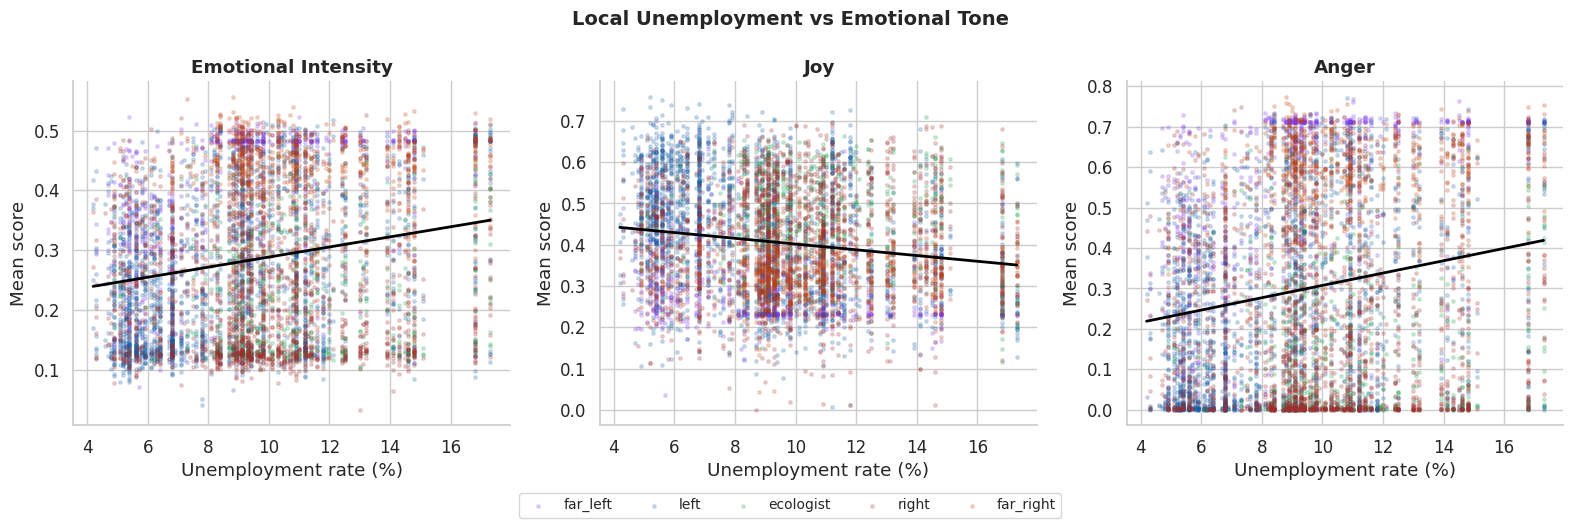

In [5]:
# ── 4. Scatter : chômage vs intensité avec courbe de tendance ────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Local Unemployment vs Emotional Tone",
             fontsize=14, fontweight="bold")

for ax, (col, label) in zip(axes, [
    ("tr_intensity_nrc", "Emotional Intensity"),
    ("tr_joy",           "Joy"),
    ("tr_anger",         "Anger"),
]):
    df_plot = df[["chomage_dept", col, "bloc"]].dropna()

    # Points colorés par bloc
    for bloc, color in BLOC_COLORS.items():
        sub = df_plot[df_plot["bloc"] == bloc]
        ax.scatter(sub["chomage_dept"], sub[col],
                   color=color, alpha=0.2, s=6, label=bloc)

    # Courbe de tendance linéaire
    x = df_plot["chomage_dept"].values
    y = df_plot[col].values
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, p(x_line), color="black", linewidth=2)

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Unemployment rate (%)")
    ax.set_ylabel("Mean score")
    ax.spines[["top", "right"]].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout()
plt.savefig("RQ3_scatter_chomage.png", dpi=150, bbox_inches="tight")
plt.show()

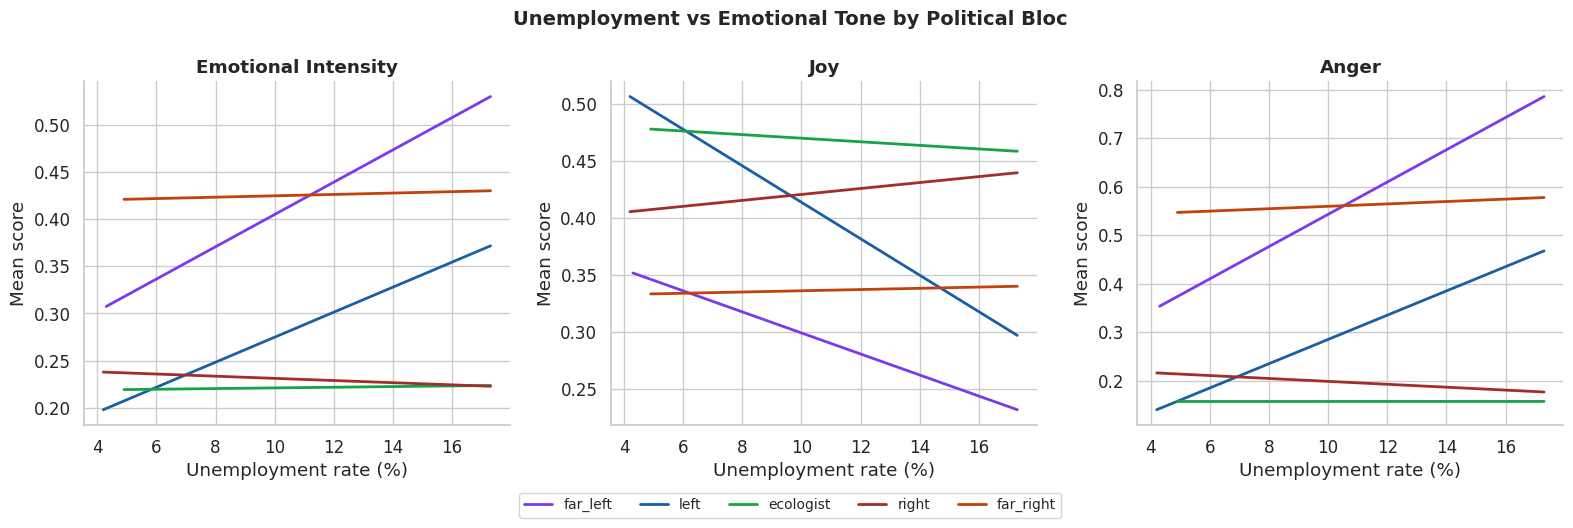

In [6]:
# ── 5. Interaction chômage × bloc ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Unemployment vs Emotional Tone by Political Bloc",
             fontsize=14, fontweight="bold")

for ax, (col, label) in zip(axes, [
    ("tr_intensity_nrc", "Emotional Intensity"),
    ("tr_joy",           "Joy"),
    ("tr_anger",         "Anger"),
]):
    for bloc, color in BLOC_COLORS.items():
        sub = df[df["bloc"] == bloc][["chomage_dept", col]].dropna()
        if len(sub) < 50:
            continue
        x = sub["chomage_dept"].values
        y = sub[col].values
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_line, p(x_line), color=color, linewidth=2, label=bloc)

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Unemployment rate (%)")
    ax.set_ylabel("Mean score")
    ax.spines[["top", "right"]].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout()
plt.savefig("RQ3_interaction_bloc.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# ── 6. OLS principal ──────────────────────────════════════════════════════
print("=" * 65)
print("OLS — unemployment predicts emotional tone")
print("controlling for bloc and year")
print("=" * 65)

for col, label in [
    ("tr_intensity_nrc", "Intensity"),
    ("tr_joy",           "Joy"),
    ("tr_anger",         "Anger"),
    ("tr_fear",          "Fear"),
    ("tr_sadness",       "Sadness"),
]:
    model = smf.ols(
        f"{col} ~ chomage_dept + C(bloc, Treatment('left')) + C(year_dummy)",
        data=df.dropna(subset=[col, "chomage_dept", "bloc", "year_dummy"])
    ).fit()
    coef = model.params["chomage_dept"]
    pval = model.pvalues["chomage_dept"]
    stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
    print(f"  {label:12} : β={coef:+.4f}  p={pval:.4f}  {stars}  R²={model.rsquared:.3f}")

OLS — unemployment predicts emotional tone
controlling for bloc and year
  Intensity    : β=+0.0018  p=0.0016  **  R²=0.365
  Joy          : β=-0.0011  p=0.1130  n.s.  R²=0.194


  Anger        : β=+0.0038  p=0.0005  ***  R²=0.373
  Fear         : β=+0.0015  p=0.0799  n.s.  R²=0.250
  Sadness      : β=+0.0021  p=0.0085  **  R²=0.271


## 3. OLS — Does Unemployment Predict Emotional Tone?

Controlling for ideological bloc and electoral year, local unemployment is a 
significant predictor of intensity (β = +0.0018, p < 0.01) and anger 
(β = +0.0038, p < 0.001). Each additional percentage point of unemployment is 
associated with a small but significant increase in both measures.

Joy and fear are not significant once bloc and year are controlled for, suggesting 
that the unemployment effect on these emotions is largely absorbed by ideological 
composition — left-leaning departments may have both higher unemployment and higher 
joy scores, confounding the raw correlation.

Sadness is marginally significant (β = +0.0021, p < 0.01), consistent with a 
general shift toward negative affect in economically distressed areas.

In [8]:
# ── 7. OLS avec interaction chômage × bloc ───────────────────────────────
print("=" * 65)
print("OLS — interaction unemployment × bloc")
print("=" * 65)

for col, label in [
    ("tr_intensity_nrc", "Intensity"),
    ("tr_joy",           "Joy"),
    ("tr_anger",         "Anger"),
]:
    model = smf.ols(
        f"{col} ~ chomage_dept * C(bloc, Treatment('left')) + C(year_dummy)",
        data=df.dropna(subset=[col, "chomage_dept", "bloc", "year_dummy"])
    ).fit()
    print(f"\n── {label} — R²={model.rsquared:.4f} | N={int(model.nobs):,} ──")
    for name, coef, pval in zip(
        model.params.index, model.params.values, model.pvalues.values
    ):
        if "chomage" in name:
            stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
            print(f"  {name:60} β={coef:+.4f}  p={pval:.4f}  {stars}")

OLS — interaction unemployment × bloc

── Intensity — R²=0.3870 | N=6,371 ──
  chomage_dept                                                 β=+0.0075  p=0.0000  ***
  chomage_dept:C(bloc, Treatment('left'))[T.ecologist]         β=-0.0091  p=0.0000  ***
  chomage_dept:C(bloc, Treatment('left'))[T.far_left]          β=+0.0038  p=0.0055  **
  chomage_dept:C(bloc, Treatment('left'))[T.far_right]         β=-0.0088  p=0.0000  ***
  chomage_dept:C(bloc, Treatment('left'))[T.right]             β=-0.0137  p=0.0000  ***

── Joy — R²=0.2199 | N=6,371 ──
  chomage_dept                                                 β=-0.0099  p=0.0000  ***
  chomage_dept:C(bloc, Treatment('left'))[T.ecologist]         β=+0.0104  p=0.0000  ***
  chomage_dept:C(bloc, Treatment('left'))[T.far_left]          β=+0.0068  p=0.0000  ***
  chomage_dept:C(bloc, Treatment('left'))[T.far_right]         β=+0.0126  p=0.0000  ***
  chomage_dept:C(bloc, Treatment('left'))[T.right]             β=+0.0179  p=0.0000  ***

── Anger —

## 4. Interaction: Unemployment × Bloc

The interaction model reveals that the unemployment effect is not uniform across 
blocs — and the heterogeneity is striking.

**Intensity**: the baseline unemployment effect (for the left, reference bloc) is 
positive and significant (β = +0.0075, p < 0.001). The mainstream right and 
far-right show significant *negative* interactions (β = −0.0137 and β = −0.0088), 
meaning their intensity actually *decreases* with unemployment. The far-left shows 
a positive interaction (β = +0.0038), amplifying the baseline effect.

**Joy**: the baseline effect for the left is strongly negative (β = −0.0099, 
p < 0.001) — left candidates in high-unemployment departments are markedly less 
positive. All other blocs show positive interactions, meaning the joy penalty from 
unemployment is specific to the left. For the right (β = +0.0179) and far-right 
(β = +0.0126), higher unemployment is actually associated with *more* joy — 
consistent with an opposition framing where economic hardship is a political 
opportunity.

**Anger**: the pattern mirrors intensity. The left's anger increases with 
unemployment (β = +0.0147), while the right and far-right show strong negative 
interactions — they do not mobilise anger in response to local economic distress.

This asymmetry is substantively important: the left responds to local unemployment 
with more emotional intensity and less positivity; the right responds with less 
intensity and, counterintuitively, more joy.

In [9]:
# ── 8. Sensitivity : par année ────────────────────────────────────────────
print("=" * 65)
print("SENSITIVITY — OLS by year")
print("=" * 65)

for year in [1981, 1993]:
    df_year = df[df["year"] == year].copy()
    print(f"\n── YEAR {year} — N={len(df_year):,} ──")
    for col, label in [("tr_intensity_nrc", "Intensity"),
                       ("tr_joy", "Joy"), ("tr_anger", "Anger")]:
        model = smf.ols(
            f"{col} ~ chomage_dept + C(bloc, Treatment('left'))",
            data=df_year.dropna(subset=[col, "chomage_dept", "bloc"])
        ).fit()
        coef = model.params["chomage_dept"]
        pval = model.pvalues["chomage_dept"]
        stars = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
        print(f"  {label:12} : β={coef:+.4f}  p={pval:.4f}  {stars}")

SENSITIVITY — OLS by year

── YEAR 1981 — N=2,388 ──
  Intensity    : β=+0.0006  p=0.5312  n.s.
  Joy          : β=+0.0017  p=0.1779  n.s.
  Anger        : β=+0.0021  p=0.2871  n.s.

── YEAR 1993 — N=4,058 ──
  Intensity    : β=+0.0016  p=0.0141  *
  Joy          : β=-0.0014  p=0.0512  n.s.
  Anger        : β=+0.0032  p=0.0097  **


## Conclusion

Local unemployment predicts emotional tone, but the effect is small and 
heterogeneous across blocs. The aggregate effect — higher unemployment associated 
with more intensity and anger — is driven almost entirely by left-wing candidates. 
Left candidates in high-unemployment departments write more intensely and less 
positively, consistent with a rhetoric of economic denunciation.

Right and far-right candidates show the opposite pattern: in high-unemployment 
areas, they become *less* intense and *more* joyful — consistent with an opposition 
strategy of optimistic contrast rather than emotional mobilisation.

The effect is absent in 1981 and emerges only in 1993, when unemployment variation 
across departments was large enough to generate detectable rhetorical differences. 
This limits the generalisability of the finding to periods of significant economic 
disparity.